#AUTOENCODERS
---

##0.REFERENCE AND CONTEXT

**Notebook title: Autoencoders for Representation Learning with Fashion-MNIST**

**Introduction**

Autoencoders are one of the most important first models for teaching unsupervised representation learning. In the previous tutorials, the models were trained to predict labels. The dense neural network predicted digit classes. The embedding model predicted movie review sentiment. The convolutional neural network predicted clothing categories. The recurrent neural network predicted sentiment from ordered text. In all of those cases, the model received an input and learned to predict an external target. The autoencoder changes the learning problem. Instead of learning to predict a separate label, it learns to reconstruct its own input.

This shift is conceptually powerful. An autoencoder receives an image, compresses it into a smaller internal representation, and then tries to reconstruct the original image from that compressed representation. The first part of the model is called the encoder. The encoder maps the input image into a latent vector. The latent vector is a compressed numerical summary of the image. The second part of the model is called the decoder. The decoder takes the latent vector and attempts to rebuild the original image. The model learns by minimizing reconstruction error: the difference between the original image and the reconstructed image.

Fashion-MNIST is an excellent dataset for this tutorial because we already used it for convolutional neural networks. In the CNN notebook, the question was: what class is this image? In the autoencoder notebook, the question becomes: can the model compress this image and reconstruct it? This gives students a clean contrast between supervised classification and unsupervised representation learning.

The autoencoder is also a natural bridge toward generative models. A basic autoencoder is not yet a full probabilistic generator, but it introduces the essential architecture of encoding and decoding. Later, this structure will evolve into denoising autoencoders, variational autoencoders, and other generative systems. Students will begin to see that modern AI is not only about predicting labels; it is also about learning useful internal spaces.

In this notebook, we build a simple dense autoencoder. Each 28 by 28 Fashion-MNIST image is flattened into a vector of 784 pixel values. The encoder compresses this vector into a smaller latent representation. The decoder reconstructs the image from that latent vector. We visualize original images next to reconstructed images so students can directly inspect what the model has learned.

We also visualize the latent space. After training, we pass test images through the encoder and obtain latent vectors. Then we reduce those vectors to two dimensions using principal component analysis. Although the autoencoder is not trained with labels, we color the latent-space plot using the true Fashion-MNIST classes for interpretation. If similar items cluster near one another, students can see that the autoencoder has learned structure from the images even without being explicitly trained as a classifier.

As in the rest of the project, the notebook follows the 10 cell plus 1 structure. The implementation cells create the experiment, train the model, evaluate reconstructions, visualize the latent space, and save artifacts. The additional LLM cell uses GPT-5.2 to explain the results in structured JSON.

##1.LIBRARIES AND ENVIRONMENT

**Explanation for Cell 1**

This cell prepares the notebook environment. It imports the libraries, fixes random seeds, creates output folders, and writes a run manifest. The manifest records the execution environment and makes the experiment easier to reproduce and audit.

In [13]:
import os
import json
import random
import platform
import datetime
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

PROJECT_DIR = Path("/content/autoencoder_fashion_mnist_project")
ARTIFACT_DIR = PROJECT_DIR / "artifacts"
MODEL_DIR = PROJECT_DIR / "model"

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

RUN_ID = datetime.datetime.now(datetime.timezone.utc).strftime("run_%Y%m%d_%H%M%S_utc")

environment_manifest = {
    "run_id": RUN_ID,
    "created_at_utc": datetime.datetime.now(datetime.timezone.utc).isoformat(),
    "python_version": platform.python_version(),
    "platform": platform.platform(),
    "tensorflow_version": tf.__version__,
    "numpy_version": np.__version__,
    "seed": SEED
}

manifest_path = ARTIFACT_DIR / "run_manifest.json"

with open(manifest_path, "w", encoding="utf-8") as f:
    json.dump(environment_manifest, f, indent=2)

print("Run ID:", RUN_ID)
print("TensorFlow version:", tf.__version__)
print("Artifacts folder:", ARTIFACT_DIR)

Run ID: run_20260604_183233_utc
TensorFlow version: 2.20.0
Artifacts folder: /content/autoencoder_fashion_mnist_project/artifacts


##2.THE MINST FASHON DATASET

**Explanation for Cell 2**

This cell loads the Fashion-MNIST dataset. In this notebook, the labels are not used for training because the autoencoder learns to reconstruct images rather than classify them. The labels are still useful later for interpreting the latent space.

In [14]:
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = keras.datasets.fashion_mnist.load_data()

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

dataset_summary = {
    "training_images": int(X_train_raw.shape[0]),
    "test_images": int(X_test_raw.shape[0]),
    "image_height": int(X_train_raw.shape[1]),
    "image_width": int(X_train_raw.shape[2]),
    "number_of_classes": int(len(class_names)),
    "class_names": class_names,
    "training_use_of_labels": "Labels are not used for autoencoder training. They are used only for interpretation."
}

label_counts = {
    class_names[int(label)]: int(count)
    for label, count in zip(*np.unique(y_train_raw, return_counts=True))
}

print("Dataset summary")
print(json.dumps(dataset_summary, indent=2))

print("\nTraining label counts")
print(json.dumps(label_counts, indent=2))

Dataset summary
{
  "training_images": 60000,
  "test_images": 10000,
  "image_height": 28,
  "image_width": 28,
  "number_of_classes": 10,
  "class_names": [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
  ],
  "training_use_of_labels": "Labels are not used for autoencoder training. They are used only for interpretation."
}

Training label counts
{
  "T-shirt/top": 6000,
  "Trouser": 6000,
  "Pullover": 6000,
  "Dress": 6000,
  "Coat": 6000,
  "Sandal": 6000,
  "Shirt": 6000,
  "Sneaker": 6000,
  "Bag": 6000,
  "Ankle boot": 6000
}


##3.VISUALIZATION

**Explanation for Cell 3**

This cell displays sample images from Fashion-MNIST. Since the autoencoder will try to reconstruct these images, students should first inspect the visual structure of the data. This helps them understand what kind of information the model must preserve through compression.

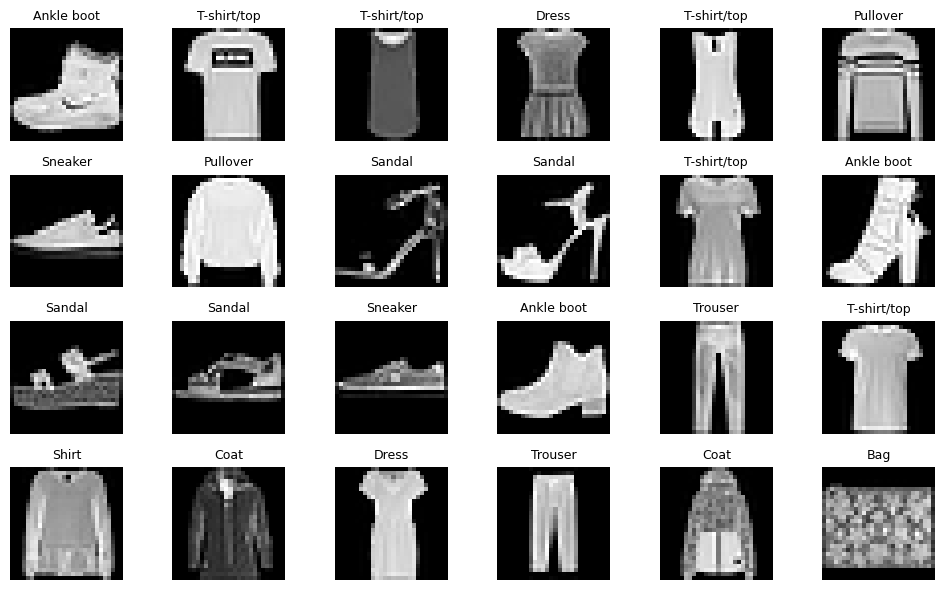

Saved sample image grid to: /content/autoencoder_fashion_mnist_project/artifacts/fashion_mnist_sample_grid.png


In [15]:
plt.figure(figsize=(10, 6))

for i in range(24):
    plt.subplot(4, 6, i + 1)
    plt.imshow(X_train_raw[i], cmap="gray")
    plt.title(class_names[int(y_train_raw[i])], fontsize=9)
    plt.axis("off")

plt.tight_layout()

sample_grid_path = ARTIFACT_DIR / "fashion_mnist_sample_grid.png"
plt.savefig(sample_grid_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved sample image grid to:", sample_grid_path)

##4.DATA PREPROCESSING

**Explanation for Cell 4**

This cell preprocesses the images. Pixel values are scaled from the original 0 to 255 range into the 0 to 1 range. Each 28 by 28 image is also flattened into a vector of 784 values. For this first autoencoder, we use a dense architecture rather than a convolutional architecture so that the encoder and decoder structure is easy to see.

In [16]:
X_train_scaled = X_train_raw.astype("float32") / 255.0
X_test_scaled = X_test_raw.astype("float32") / 255.0

X_train_flat = X_train_scaled.reshape((X_train_scaled.shape[0], 28 * 28))
X_test_flat = X_test_scaled.reshape((X_test_scaled.shape[0], 28 * 28))

X_train = X_train_flat[:50000]
X_val = X_train_flat[50000:]

y_train = y_train_raw[:50000]
y_val = y_train_raw[50000:]

split_summary = {
    "training_samples": int(X_train.shape[0]),
    "validation_samples": int(X_val.shape[0]),
    "test_samples": int(X_test_flat.shape[0]),
    "flattened_input_dimension": int(X_train.shape[1]),
    "original_image_shape": [28, 28]
}

print(json.dumps(split_summary, indent=2))
print("Training matrix shape:", X_train.shape)
print("Validation matrix shape:", X_val.shape)
print("Test matrix shape:", X_test_flat.shape)

{
  "training_samples": 50000,
  "validation_samples": 10000,
  "test_samples": 10000,
  "flattened_input_dimension": 784,
  "original_image_shape": [
    28,
    28
  ]
}
Training matrix shape: (50000, 784)
Validation matrix shape: (10000, 784)
Test matrix shape: (10000, 784)


##5.TENSORFLOW DATASETS

**Explanation for Cell 5**

This cell creates TensorFlow datasets. Notice that the input and target are the same image vector. This is the defining feature of an autoencoder training setup. The model receives an image and tries to output that same image after passing through a compressed latent representation.

In [21]:
BATCH_SIZE = 128

# Shuffle X_train with numpy to avoid tf.data.Dataset.shuffle GPU issues
idx = np.arange(len(X_train))
np.random.shuffle(idx)

X_train_shuffled = X_train[idx]
y_train_shuffled = X_train[idx] # For autoencoder, input and target are the same

train_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_train_shuffled, y_train_shuffled))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_val, X_val))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_test_flat, X_test_flat))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

for batch_X, batch_y in train_ds.take(1):
    print("Input batch shape:", batch_X.shape)
    print("Target batch shape:", batch_y.shape)
    print("Are input and target identical for first batch:", np.allclose(batch_X.numpy(), batch_y.numpy()))

Input batch shape: (128, 784)
Target batch shape: (128, 784)
Are input and target identical for first batch: True


##6.BUILDING THE AUTOENCODER

**Explanation for Cell 6**

This cell builds the autoencoder. The encoder compresses the 784-pixel input into a smaller latent vector. The decoder then reconstructs the 784-pixel image from that latent vector. The sigmoid output is appropriate because pixel values were scaled into the 0 to 1 range.

In [28]:
INPUT_DIM = 28 * 28
LATENT_DIM = 32

keras.backend.clear_session() # Clear the Keras session to reset GPU context

def build_dense_autoencoder(input_dim=INPUT_DIM, latent_dim=LATENT_DIM):
    with tf.device('/cpu:0'): # Force model building on CPU to avoid GPU context issues
        encoder_input = keras.Input(shape=(input_dim,), name="image_input")

        x = layers.Dense(256, activation="relu", name="encoder_dense_1")(encoder_input)
        x = layers.Dense(128, activation="relu", name="encoder_dense_2")(x)
        latent = layers.Dense(latent_dim, activation="relu", name="latent_vector")(x)

        encoder = keras.Model(
            inputs=encoder_input,
            outputs=latent,
            name="fashion_mnist_encoder"
        )

        decoder_input = keras.Input(shape=(latent_dim,), name="latent_input")

        x = layers.Dense(128, activation="relu", name="decoder_dense_1")(decoder_input)
        x = layers.Dense(256, activation="relu", name="decoder_dense_2")(x)
        reconstruction = layers.Dense(input_dim, activation="sigmoid", name="reconstructed_image")(x)

        decoder = keras.Model(
            inputs=decoder_input,
            outputs=reconstruction,
            name="fashion_mnist_decoder"
        )

        autoencoder_output = decoder(encoder(encoder_input))

        autoencoder = keras.Model(
            inputs=encoder_input,
            outputs=autoencoder_output,
            name="fashion_mnist_dense_autoencoder"
        )

    return encoder, decoder, autoencoder

encoder, decoder, autoencoder = build_dense_autoencoder()

print("Encoder summary")
encoder.summary()

print("\nDecoder summary")
decoder.summary()

print("\nAutoencoder summary")
autoencoder.summary()

Encoder summary


Model: "fashion_mnist_encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dense_1 (Dense)         │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dense_2 (Dense)         │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_vector (Dense)           │ (None, 32)             │         4,128 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 237,984 (929.62 KB)

 Trainable params: 237,984 (929.62 KB)

...

Model: "fashion_mnist_dense_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fashion_mnist_encoder           │ (None, 32)             │       237,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fashion_mnist_decoder           │ (None, 784)            │       238,736 │
│ (Functional)                    │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 476,720 (1.82 MB)

 Trainable params: 476,720 (1.82 MB)

 Non-trainable params: 0 (0.00 B)

##7.COMPILATION AND TRAINING

**Explanation for Cell 7**

This cell compiles and trains the autoencoder. The loss function is mean squared error, which measures the average squared difference between the original pixel values and the reconstructed pixel values. The model learns by improving the reconstruction of its own inputs.

In [31]:
with tf.device('/cpu:0'): # Force compilation on CPU to avoid GPU context issues
    autoencoder.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="mse",
        metrics=["mae"]
    )

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

with tf.device('/cpu:0'): # Force training on CPU to avoid GPU context issues
    history = autoencoder.fit(
        train_ds,
        validation_data=val_ds,
        epochs=50,
        callbacks=[early_stopping],
        verbose=1
    )

history_dict = {
    key: [float(value) for value in values]
    for key, values in history.history.items()
}

history_path = ARTIFACT_DIR / "training_history.json"

with open(history_path, "w", encoding="utf-8") as f:
    json.dump(history_dict, f, indent=2)

print("Training history saved to:", history_path)

Epoch 1/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0347 - mae: 0.1135 - val_loss: 0.0206 - val_mae: 0.0822
Epoch 2/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0185 - mae: 0.0768 - val_loss: 0.0170 - val_mae: 0.0724
Epoch 3/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0160 - mae: 0.0700 - val_loss: 0.0153 - val_mae: 0.0682
Epoch 4/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0147 - mae: 0.0663 - val_loss: 0.0142 - val_mae: 0.0652
Epoch 5/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0137 - mae: 0.0637 - val_loss: 0.0135 - val_mae: 0.0629
Epoch 6/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0130 - mae: 0.0616 - val_loss: 0.0129 - val_mae: 0.0611
Epoch 7/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0125 - mae: 0.0602 - val_loss: 0.0124 - val_mae: 0.0596
Epoch 8/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0120 - mae: 0.0587 - val_loss: 0.0120 - val_mae: 0.0584
Epoch 9/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - lo

##8.EVALUATION

**Explanation for Cell 8**

This cell evaluates the reconstruction performance. It plots training and validation loss, computes test reconstruction error, and displays original images next to reconstructed images. This visual comparison is the most important result of the notebook because students can directly see what the compressed latent representation preserved and what it lost.

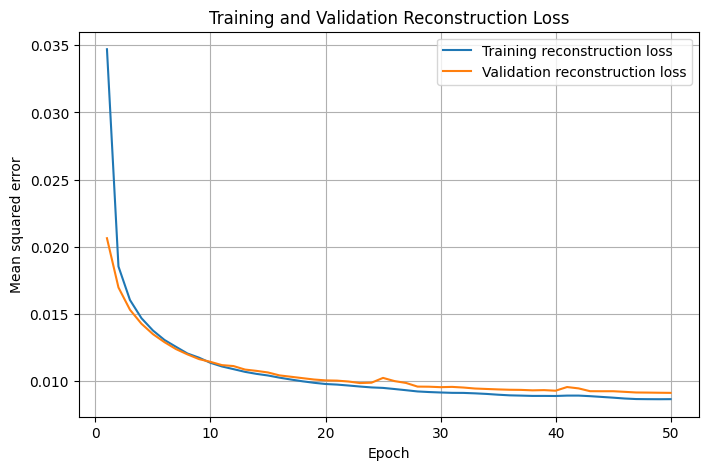

Reconstruction summary
{
  "test_mse_loss": 0.009085661731660366,
  "test_mae": 0.04865200072526932,
  "mean_per_image_mse": 0.009085659869015217,
  "median_per_image_mse": 0.006990394555032253,
  "minimum_per_image_mse": 0.0009784287540242076,
  "maximum_per_image_mse": 0.09947697073221207
}


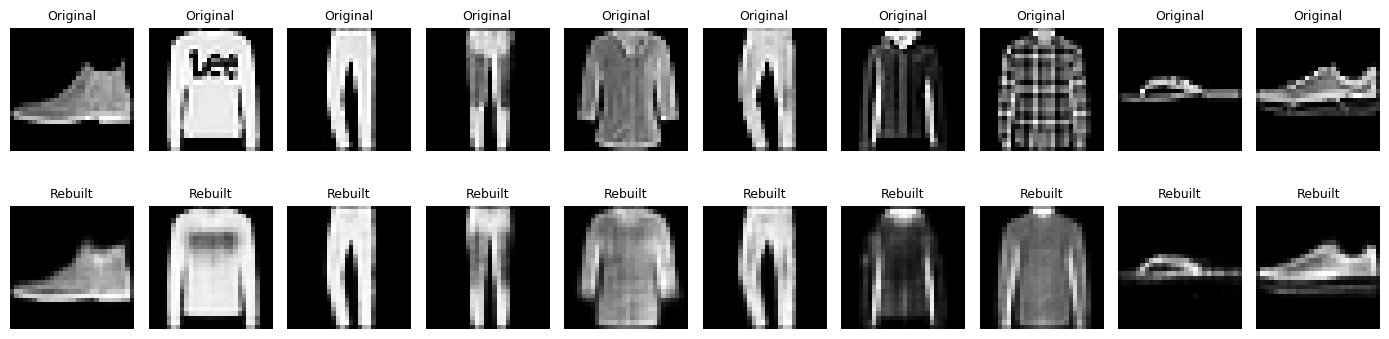

Saved reconstruction loss curve to: /content/autoencoder_fashion_mnist_project/artifacts/reconstruction_loss_curve.png
Saved reconstruction summary to: /content/autoencoder_fashion_mnist_project/artifacts/reconstruction_summary.json
Saved reconstruction grid to: /content/autoencoder_fashion_mnist_project/artifacts/original_vs_reconstructed_grid.png


In [33]:
epochs_ran = range(1, len(history.history["loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_ran, history.history["loss"], label="Training reconstruction loss")
plt.plot(epochs_ran, history.history["val_loss"], label="Validation reconstruction loss")
plt.xlabel("Epoch")
plt.ylabel("Mean squared error")
plt.title("Training and Validation Reconstruction Loss")
plt.legend()
plt.grid(True)

loss_plot_path = ARTIFACT_DIR / "reconstruction_loss_curve.png"
plt.savefig(loss_plot_path, dpi=150, bbox_inches="tight")
plt.show()

with tf.device('/cpu:0'): # Force evaluation on CPU
    test_loss, test_mae = autoencoder.evaluate(test_ds, verbose=0)

with tf.device('/cpu:0'): # Force prediction on CPU
    X_test_reconstructed = autoencoder.predict(X_test_flat, verbose=0)

per_image_mse = np.mean(
    np.square(X_test_flat - X_test_reconstructed),
    axis=1
)

reconstruction_summary = {
    "test_mse_loss": float(test_loss),
    "test_mae": float(test_mae),
    "mean_per_image_mse": float(np.mean(per_image_mse)),
    "median_per_image_mse": float(np.median(per_image_mse)),
    "minimum_per_image_mse": float(np.min(per_image_mse)),
    "maximum_per_image_mse": float(np.max(per_image_mse))
}

reconstruction_summary_path = ARTIFACT_DIR / "reconstruction_summary.json"

with open(reconstruction_summary_path, "w", encoding="utf-8") as f:
    json.dump(reconstruction_summary, f, indent=2)

print("Reconstruction summary")
print(json.dumps(reconstruction_summary, indent=2))

display_count = 10

plt.figure(figsize=(14, 4))

for i in range(display_count):
    plt.subplot(2, display_count, i + 1)
    plt.imshow(X_test_flat[i].reshape(28, 28), cmap="gray")
    plt.title("Original", fontsize=9)
    plt.axis("off")

    plt.subplot(2, display_count, i + 1 + display_count)
    plt.imshow(X_test_reconstructed[i].reshape(28, 28), cmap="gray")
    plt.title("Rebuilt", fontsize=9)
    plt.axis("off")

plt.tight_layout()

reconstruction_grid_path = ARTIFACT_DIR / "original_vs_reconstructed_grid.png"
plt.savefig(reconstruction_grid_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved reconstruction loss curve to:", loss_plot_path)
print("Saved reconstruction summary to:", reconstruction_summary_path)
print("Saved reconstruction grid to:", reconstruction_grid_path)

##9.VISUALIZATION OF THE LATENT SPACE

**Explanation for Cell 9**

This cell visualizes the latent space learned by the encoder. The encoder converts each image into a 32-dimensional latent vector. We reduce those latent vectors to two dimensions using principal component analysis. The model was not trained with labels, but we color the points using the true labels so students can inspect whether similar clothing categories appear near one another.

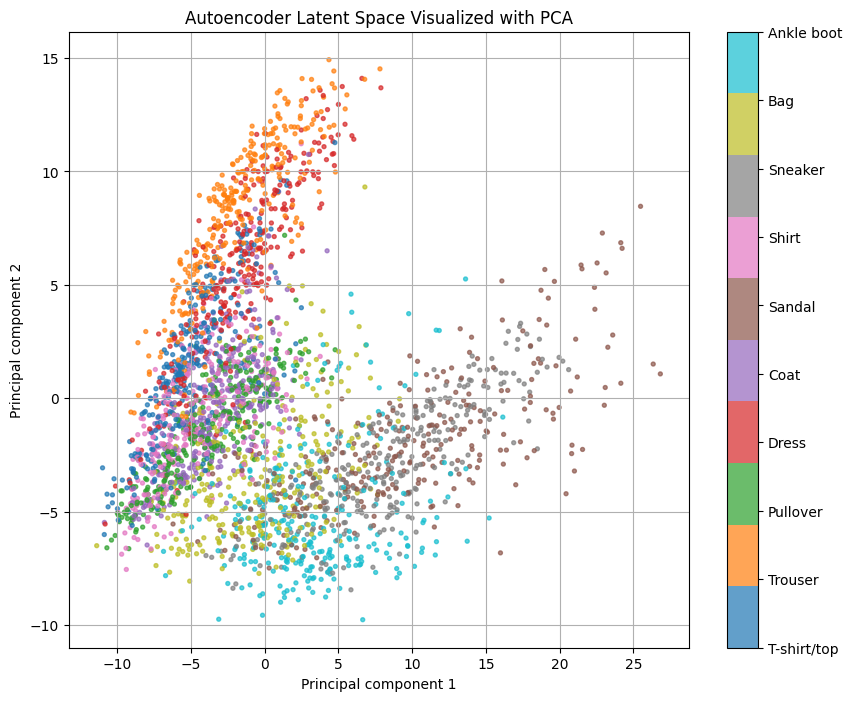

Latent vector shape: (3000, 32)
PCA explained variance ratio: [0.30165014 0.1793505 ]
Saved latent coordinates to: /content/autoencoder_fashion_mnist_project/artifacts/latent_space_pca_coordinates.json
Saved latent space plot to: /content/autoencoder_fashion_mnist_project/artifacts/latent_space_pca_plot.png


In [36]:
LATENT_SAMPLE_SIZE = 3000

with tf.device('/cpu:0'): # Force encoder prediction on CPU
    latent_vectors = encoder.predict(X_test_flat[:LATENT_SAMPLE_SIZE], verbose=0)
latent_labels = y_test_raw[:LATENT_SAMPLE_SIZE]

pca = PCA(n_components=2, random_state=SEED)
latent_vectors_2d = pca.fit_transform(latent_vectors)

latent_records = []

for i in range(LATENT_SAMPLE_SIZE):
    latent_records.append(
        {
            "test_index": int(i),
            "class_id": int(latent_labels[i]),
            "class_name": class_names[int(latent_labels[i])],
            "pca_1": float(latent_vectors_2d[i, 0]),
            "pca_2": float(latent_vectors_2d[i, 1])
        }
    )

latent_coordinates_path = ARTIFACT_DIR / "latent_space_pca_coordinates.json"

with open(latent_coordinates_path, "w", encoding="utf-8") as f:
    json.dump(latent_records, f, indent=2)

plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    latent_vectors_2d[:, 0],
    latent_vectors_2d[:, 1],
    c=latent_labels,
    cmap="tab10",
    s=8,
    alpha=0.70
)

plt.xlabel("Principal component 1")
plt.ylabel("Principal component 2")
plt.title("Autoencoder Latent Space Visualized with PCA")
plt.grid(True)

colorbar = plt.colorbar(scatter, ticks=range(10))
colorbar.ax.set_yticklabels(class_names)

latent_plot_path = ARTIFACT_DIR / "latent_space_pca_plot.png"
plt.savefig(latent_plot_path, dpi=150, bbox_inches="tight")
plt.show()

print("Latent vector shape:", latent_vectors.shape)
print("PCA explained variance ratio:", pca.explained_variance_ratio_)
print("Saved latent coordinates to:", latent_coordinates_path)
print("Saved latent space plot to:", latent_plot_path)

##10.SAVING THE ENCODER DECODER

**Explanation for Cell 10**

This cell saves the trained encoder, decoder, and full autoencoder. It also stores examples with the best and worst reconstruction errors. These examples help students inspect where the model performs well and where compression loses important detail.

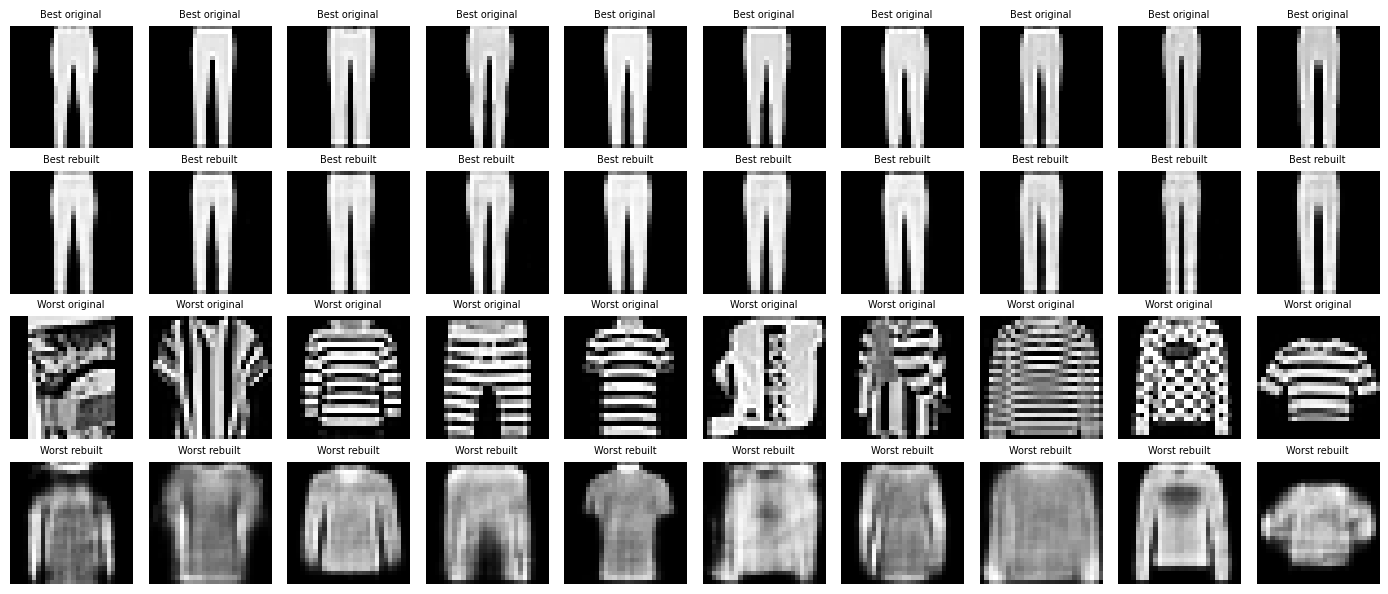

Saved reconstruction error records to: /content/autoencoder_fashion_mnist_project/artifacts/reconstruction_error_records.json
Saved best and worst reconstruction grid to: /content/autoencoder_fashion_mnist_project/artifacts/best_and_worst_reconstructions.png
Saved encoder to: /content/autoencoder_fashion_mnist_project/model/fashion_mnist_encoder.keras
Saved decoder to: /content/autoencoder_fashion_mnist_project/model/fashion_mnist_decoder.keras
Saved autoencoder to: /content/autoencoder_fashion_mnist_project/model/fashion_mnist_autoencoder.keras


In [38]:
sorted_indices = np.argsort(per_image_mse)

best_indices = sorted_indices[:10]
worst_indices = sorted_indices[-10:][::-1]

reconstruction_error_records = []

for i in range(len(per_image_mse)):
    reconstruction_error_records.append(
        {
            "test_index": int(i),
            "class_id": int(y_test_raw[i]),
            "class_name": class_names[int(y_test_raw[i])],
            "reconstruction_mse": float(per_image_mse[i])
        }
    )

reconstruction_errors_path = ARTIFACT_DIR / "reconstruction_error_records.json"

with open(reconstruction_errors_path, "w", encoding="utf-8") as f:
    json.dump(reconstruction_error_records, f, indent=2)

plt.figure(figsize=(14, 6))

for position, image_index in enumerate(best_indices):
    plt.subplot(4, 10, position + 1)
    plt.imshow(X_test_flat[image_index].reshape(28, 28), cmap="gray")
    plt.title("Best original", fontsize=7)
    plt.axis("off")

    plt.subplot(4, 10, position + 11)
    plt.imshow(X_test_reconstructed[image_index].reshape(28, 28), cmap="gray")
    plt.title("Best rebuilt", fontsize=7)
    plt.axis("off")

for position, image_index in enumerate(worst_indices):
    plt.subplot(4, 10, position + 21)
    plt.imshow(X_test_flat[image_index].reshape(28, 28), cmap="gray")
    plt.title("Worst original", fontsize=7)
    plt.axis("off")

    plt.subplot(4, 10, position + 31)
    plt.imshow(X_test_reconstructed[image_index].reshape(28, 28), cmap="gray")
    plt.title("Worst rebuilt", fontsize=7)
    plt.axis("off")

plt.tight_layout()

best_worst_path = ARTIFACT_DIR / "best_and_worst_reconstructions.png"
plt.savefig(best_worst_path, dpi=150, bbox_inches="tight")
plt.show()

encoder_path = MODEL_DIR / "fashion_mnist_encoder.keras"
decoder_path = MODEL_DIR / "fashion_mnist_decoder.keras"
autoencoder_path = MODEL_DIR / "fashion_mnist_autoencoder.keras"

with tf.device('/cpu:0'): # Force saving on CPU
    encoder.save(encoder_path)
    decoder.save(decoder_path)
    autoencoder.save(autoencoder_path)

print("Saved reconstruction error records to:", reconstruction_errors_path)
print("Saved best and worst reconstruction grid to:", best_worst_path)
print("Saved encoder to:", encoder_path)
print("Saved decoder to:", decoder_path)
print("Saved autoencoder to:", autoencoder_path)

##11.SUMMARY AND ANALYSIS

**Explanation for the LLM Results Cell**

This cell uses GPT-5.2 to explain the autoencoder model and its results. It reads the saved training history, reconstruction summary, latent-space information, and reconstruction-error records. The output is requested as strict JSON so that observed facts, interpretation, assumptions, limitations, and next steps remain clearly separated. The API key is expected to be stored in Colab Secrets under OPENAI_API_KEY.

In [40]:
import re
from google.colab import userdata
from openai import OpenAI

OPENAI_MODEL = "gpt-5.2"

api_key = userdata.get("OPENAI_API_KEY")

if not api_key:
    raise ValueError("OPENAI_API_KEY was not found in Colab Secrets.")

client = OpenAI(api_key=api_key)

with open(history_path, "r", encoding="utf-8") as f:
    history_for_llm = json.load(f)

with open(reconstruction_summary_path, "r", encoding="utf-8") as f:
    reconstruction_for_llm = json.load(f)

with open(reconstruction_errors_path, "r", encoding="utf-8") as f:
    reconstruction_errors_for_llm = json.load(f)

with open(latent_coordinates_path, "r", encoding="utf-8") as f:
    latent_coordinates_for_llm = json.load(f)

best_examples_for_llm = sorted(
    reconstruction_errors_for_llm,
    key=lambda record: record["reconstruction_mse"]
)[:10]

worst_examples_for_llm = sorted(
    reconstruction_errors_for_llm,
    key=lambda record: record["reconstruction_mse"],
    reverse=True
)[:10]

compact_results = {
    "run_id": RUN_ID,
    "dataset_summary": dataset_summary,
    "split_summary": split_summary,
    "model_name": autoencoder.name,
    "latent_dimension": LATENT_DIM,
    "epochs_completed": len(history_for_llm["loss"]),
    "final_training_loss": history_for_llm["loss"][-1],
    "final_validation_loss": history_for_llm["val_loss"][-1],
    "reconstruction_summary": reconstruction_for_llm,
    "best_reconstruction_examples": best_examples_for_llm,
    "worst_reconstruction_examples": worst_examples_for_llm,
    "latent_space_sample_size": LATENT_SAMPLE_SIZE,
    "latent_space_artifact": str(latent_plot_path),
    "reconstruction_grid_artifact": str(reconstruction_grid_path),
    "best_worst_reconstruction_artifact": str(best_worst_path)
}

system_prompt = """
You are a machine learning instructor.
Explain an autoencoder experiment for Fashion-MNIST.
Return strict JSON only.
Do not invent results.
Separate observed facts from interpretation.
"""

user_prompt = f"""
Analyze the following experiment results.

Return JSON with this schema:

{{
  "plain_english_summary": "string",
  "why_autoencoders_matter": "string",
  "encoder_explanation": "string",
  "latent_space_explanation": "string",
  "decoder_explanation": "string",
  "reconstruction_results_explanation": "string",
  "what_best_and_worst_reconstructions_suggest": "string",
  "what_latent_space_visualization_shows": "string",
  "evidence_used": ["string"],
  "assumptions": ["string"],
  "limitations": ["string"],
  "recommended_next_steps": ["string"],
  "verification_status": "Not verified by external data"
}}

Experiment results:

BEGIN_RESULTS_JSON
{json.dumps(compact_results, indent=2)}
END_RESULTS_JSON
"""

response = client.responses.create(
    model=OPENAI_MODEL,
    input=[
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt}
    ]
)

llm_text = response.output_text.strip()

def extract_json_object(text):
    text = text.strip()
    text = re.sub(r"^```json\s*", "", text)
    text = re.sub(r"^```\s*", "", text)
    text = re.sub(r"\s*```$", "", text)

    first = text.find("{")
    last = text.rfind("}")

    if first == -1 or last == -1 or last <= first:
        raise ValueError("No JSON object found in LLM response.")

    candidate = text[first:last + 1]
    return json.loads(candidate)

llm_explanation = extract_json_object(llm_text)

llm_explanation_path = ARTIFACT_DIR / "llm_results_explanation.json"

with open(llm_explanation_path, "w", encoding="utf-8") as f:
    json.dump(llm_explanation, f, indent=2)

print(json.dumps(llm_explanation, indent=2))
print("\nLLM explanation saved to:", llm_explanation_path)

{
  "plain_english_summary": "A dense autoencoder with a 32-dimensional latent space was trained on 50,000 Fashion-MNIST images for 50 epochs and evaluated on a 10,000-image test set. The final train/validation losses were close (0.00862 vs 0.00909), and test reconstruction error was similar (test MSE \u2248 0.00909, test MAE \u2248 0.04865), suggesting stable generalization to the test set. Reconstruction quality varies widely across individual test images (per-image MSE from ~0.00098 to ~0.09948). The best reconstructions listed are all 'Trouser' examples, while the worst reconstructions are mostly 'T-shirt/top', 'Shirt', and 'Pullover', with one 'Trouser' and one 'Bag'. Artifacts were produced for a reconstruction grid, best/worst examples, and a PCA plot of latent vectors for 3,000 samples.",
  "why_autoencoders_matter": "Autoencoders learn to compress images into a compact representation and reconstruct them, which is useful for representation learning, compression, denoising, ano

##12.CONCLUSIONS

**Conclusion**

This notebook introduced autoencoders as the first major step from supervised prediction toward unsupervised representation learning. In the previous notebooks, the models learned from labeled examples. A dense neural network learned to classify digits. An embedding model learned sentiment from labeled movie reviews. A convolutional network learned clothing categories. An LSTM learned sentiment from ordered text sequences. The autoencoder changes the question. Instead of asking the model to predict an external label, we ask it to reconstruct its own input.

This is why the autoencoder is such an important teaching model. It reveals that neural networks can learn useful internal representations without direct class supervision. The model is trained with images as both inputs and targets. The encoder compresses each Fashion-MNIST image into a smaller latent vector, and the decoder tries to reconstruct the original image from that vector. The loss function measures reconstruction error, not classification error.

The central teaching result is the comparison between original and reconstructed images. Students can directly observe what information survives compression. If the reconstructed image preserves the general shape of a shoe, bag, shirt, or trouser, then the latent vector must contain meaningful visual structure. If fine details disappear, students can see the cost of compression. This makes the abstract concept of a latent representation concrete.

The notebook also visualized the learned latent space. The encoder produced a 32-dimensional vector for each image. These vectors were reduced to two dimensions using principal component analysis. The autoencoder was not trained with labels, but the plot was colored by the true Fashion-MNIST categories for interpretation. If similar categories appear near one another, it suggests that the autoencoder discovered useful structure in the data. This is one of the key ideas in representation learning: models can organize examples in meaningful ways even when the training objective is not classification.

The best and worst reconstruction examples add another layer of interpretation. The best reconstructions show the kinds of images that the autoencoder can compress and rebuild effectively. The worst reconstructions show where the model loses information or struggles with visual complexity. This is an important lesson. Unsupervised models are not magic compression machines. Their performance depends on architecture, latent dimension, training data, and reconstruction objective.

This notebook also prepares students for the next generative tutorials. A basic autoencoder introduces the encoder and decoder structure. A denoising autoencoder will extend the idea by asking the model to reconstruct clean images from corrupted ones. A variational autoencoder will make the latent space probabilistic and sampleable. A generative adversarial network will introduce adversarial generation. The autoencoder is therefore the conceptual bridge from classification to generation.

The LLM explanation cell continues the governance-first structure of the project. The neural network produces reconstruction metrics, plots, latent vectors, and saved artifacts. GPT-5.2 explains those artifacts in structured JSON, separating facts, assumptions, limitations, and recommendations. This reinforces the principle that machine learning notebooks should not end with a metric. They should produce evidence, interpretation, and reviewable outputs.

The autoencoder tutorial therefore marks a major transition in the 15-model sequence. We have moved beyond models that simply classify. We are now teaching models that learn internal spaces. That shift is essential for understanding modern AI.

## Resources